In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

In [39]:
job_df = pd.read_csv("dataset/cleaned_dataset_job.csv")

job_df.head()

,company,job_title,job_type,experience_level,skills
0,SGS,clinical data analyst,Full Time,Entry-level,"['genetics', 'sas', 'computer science', 'data ..."
1,Ocorian,aml/cft & data analyst,Full Time,Entry-level,"['agile', 'security', 'data management', 'fina..."
2,Cricut,machine learning engineer,Full Time,No Experience,"['agile', 'deep learning', 'architecture', 'aw..."
3,Bosch Group,application developer & data analyst,Full Time,Entry-level,"['power bi', 'oracle', 'rd', 'industrial', 'en..."
4,Publicis Groupe,data engineer full time (public sector) usa,Full Time,Mid-level,"['data pipelines', 'azure', 'aws', 'computer s..."


In [27]:
job_df.shape

(2903, 5)

In [28]:
job_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2903 entries, 0 to 2902
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   company           2903 non-null   str  
 1   job_title         2903 non-null   str  
 2   job_type          2903 non-null   str  
 3   experience_level  2903 non-null   str  
 4   skills            2903 non-null   str  
dtypes: str(5)
memory usage: 517.5 KB


In [29]:
job_df.isnull().sum()

company             0
job_title           0
job_type            0
experience_level    0
skills              0
dtype: int64

In [30]:
job_df.duplicated().sum()

np.int64(3)

In [31]:
job_df = job_df.drop_duplicates().copy()
job_df.shape

(2900, 5)

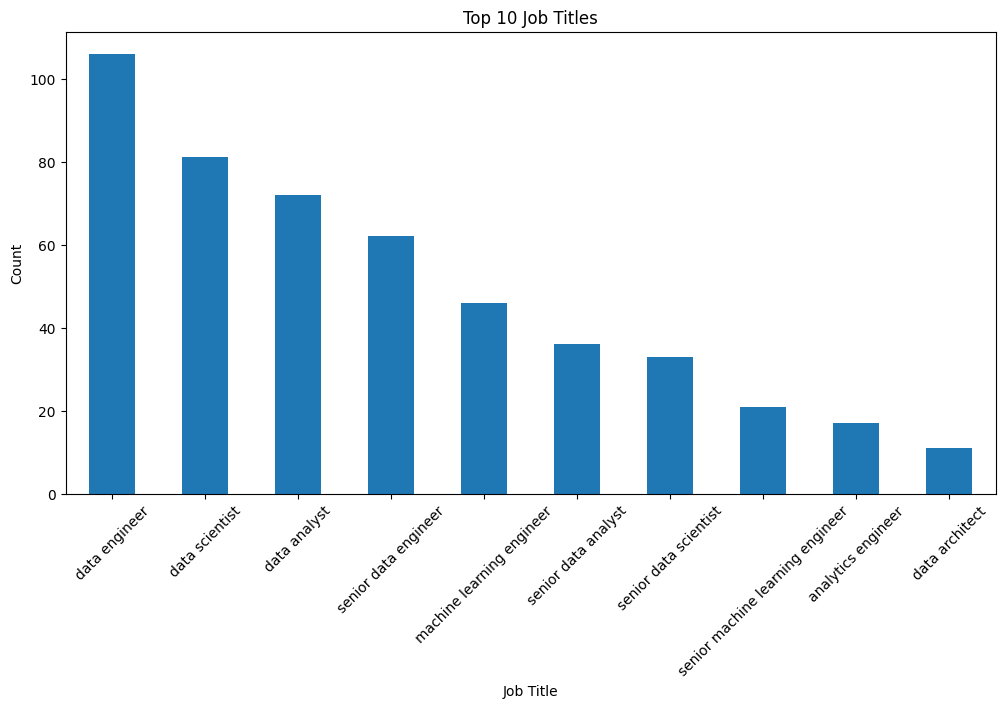

In [32]:
# Distribusi job title
top_jobs = job_df["job_title"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_jobs.plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

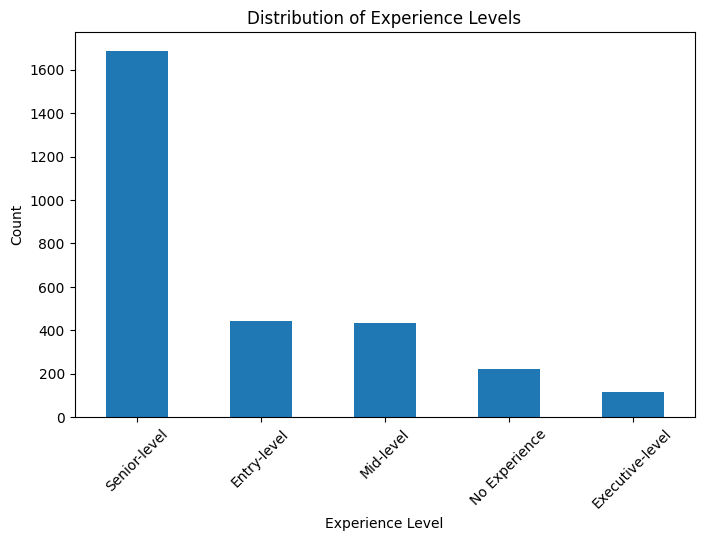

In [33]:
# Distribusi experience level
plt.figure(figsize=(8, 5))
job_df["experience_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [34]:
# extract skills
def parse_skills(skill_text):
    try:
        return ast.literal_eval(skill_text)
    except:
        return []
job_df["skills_list"] = job_df["skills"].apply(parse_skills)

In [35]:
# Top skills
all_skills = []

for skills in  job_df["skills_list"]:
    for skill in skills:
        all_skills.append(skill.lower())

        top_skills = Counter(all_skills).most_common(20)

        top_skills

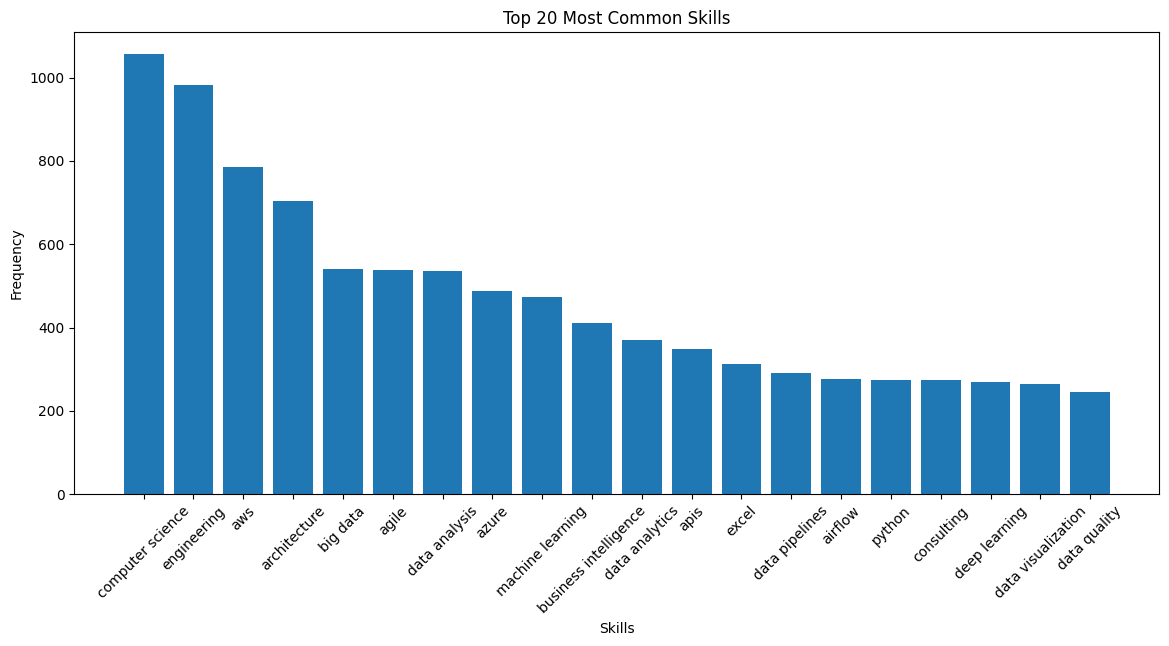

In [36]:
skills = [item[0] for item in top_skills]
counts = [item[1] for item in top_skills]

plt.figure(figsize=(14, 6))
plt.bar(skills, counts)
plt.title("Top 20 Most Common Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [37]:
# Skill per job title
job_skill_mapping = {}

for job in job_df["job_title"].value_counts().head(10).index:
    subset = job_df[job_df["job_title"] == job]

    skills_temp = []
    for skills in subset["skills_list"]:
        skills_temp.extend(skills)

    job_skill_mapping[job] = Counter(
        [skill.lower() for skill in skills_temp]
    ).most_common(10)

    job_skill_mapping

Dataset job posting ini dapat digunakan sebagai data pendukung untuk memahami kebutuhan skill pada berbagai posisi pekerjaan. Dataset ini tidak digunakan sebagai model utama, tetapi dapat membantu fitur skill gap analysis dengan cara membandingkan skill pengguna dengan skill yang banyak muncul pada job title tertentu.